<a href="https://colab.research.google.com/github/Gerardocmdz/Verano_IA_2026/blob/main/Final%20Project_Training%20a%20Machine%20Learning%20model%20on%20medical%20images./Final_Project_Training_a_Machine_Learning_model_on_medical_images_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Entrenamiento de un modelo de ML en imagenes medicas**

## ***I. Cargamos las librerias***

In [ ]:
import kagglehub
import numpy as np
import os
from termcolor import colored
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import urllib.request
import pandas as pd

## ***II. Cargando la Base de Datos que utilizaremos***

In [ ]:
#Guardamos el Token generado por Kaggle y lo cargamos
os.environ['KAGGLE_API_TOKEN'] = "KGAT_01aaa55d81348c8bbcfdd54f25e463c8"

!pip install kaggle -q

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
print("Descomprimiendo imágenes médicas...")
!unzip -qo skin-cancer-mnist-ham10000.zip
print("¡Descarga completada con éxito!")


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:24<00:00, 233MB/s]

Descomprimiendo imágenes médicas...
¡Descarga completada con éxito!


In [ ]:
ruta_metadata = "/content/HAM10000_metadata.csv"

metadata = pd.read_csv(ruta_metadata)

metadata.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


## ***III. Pre-procesamiento***

In [ ]:
print(metadata.describe())

               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


In [ ]:
val_null = metadata.isnull().sum()
print(f"Valores Nulos por columnas:\n{val_null}")

Valores Nulos por columnas:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Reemplazando valores nulos

In [ ]:
mediana = metadata.age.median()
metadata.age = metadata.age.fillna(mediana)
print(f"Reemplazamos los valores nulos por la mediana de valor: {mediana}")
val_null = metadata.isnull().sum()
print(f"Verificando si existen valores nulos:\n{val_null}")

Reemplazamos los valores nulos por la mediana de valor: 50.0
Verificando si existen valores nulos:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


In [ ]:
#tipos de cancer que queremos predecir en la piel
clases = metadata.dx.unique()
print(f"Las clases de cáncer son:\n{clases}")

Las clases de cáncer son:
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [ ]:
print(f"Cantidad de imagenes con los diferentes tipos de cancer:\n{metadata.dx.value_counts()}")

Cantidad de imagenes con los diferentes tipos de cancer:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
#Cargamos las carpetas
carpeta_cancer_piel_1 = './HAM10000_images_part_1'
carpeta_cancer_piel_2 = './HAM10000_images_part_2'

carpetas = [carpeta_cancer_piel_1 , carpeta_cancer_piel_2]

# Aquí guardaremos las rutas completas
rutas_imagenes = []

# Recorriendo carpetas
for carpeta in carpetas:
    for archivo in os.listdir(carpeta):

        if archivo.lower().endswith(('.jpeg', '.jpg', '.png')):

            ruta_completa = os.path.join(carpeta, archivo)
            rutas_imagenes.append(ruta_completa)

print(f"Número de imágenes encontradas: {len(rutas_imagenes)}")


Número de imágenes encontradas: 10015


In [ ]:
#Guardamos los titulos de las imagenes sin .jpg
diccionario_rutas = {}

for ruta in rutas_imagenes:
    nombre_archivo = os.path.basename(ruta)
    image_id = os.path.splitext(nombre_archivo)[0]
    diccionario_rutas[image_id] = ruta


Mostraremos la primera imagen para comprobar si se cargo correctamente


Título de la imagen: ISIC_0025422
Ruta completa: ./HAM10000_images_part_1/ISIC_0025422.jpg
Resolución original: 600 x 450 píxeles


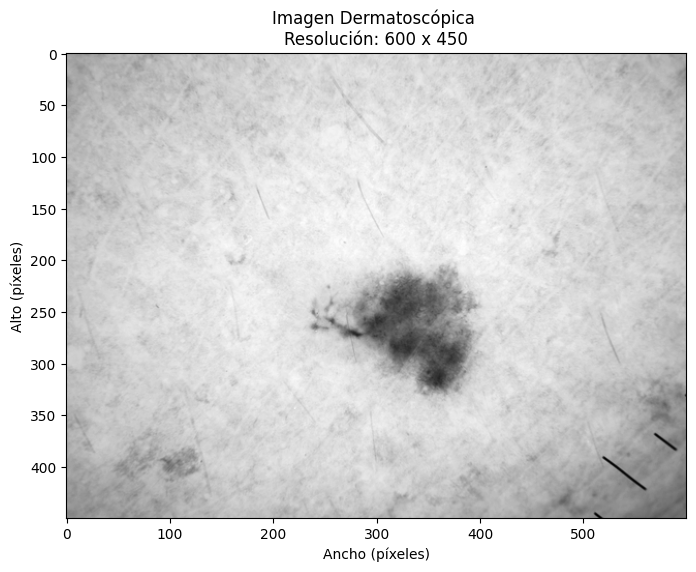

In [ ]:
ruta_prueba = rutas_imagenes[0]

nom_archivo = os.path.basename(ruta_prueba)
image_id_pr = os.path.splitext(nom_archivo)[0]
img_prueba = cv2.imread(ruta_prueba,cv2.IMREAD_GRAYSCALE)

alto, ancho = img_prueba.shape


print(f"Título de la imagen: {image_id_pr}")
print(f"Ruta completa: {ruta_prueba}")
print(f"Resolución original: {ancho} x {alto} píxeles")

plt.figure(figsize=(8, 8))
plt.imshow(img_prueba, cmap='gray')
plt.title(f"Imagen Dermatoscópica \nResolución: {ancho} x {alto}")
plt.xlabel("Ancho (píxeles)")
plt.ylabel("Alto (píxeles)")
plt.grid(False)
plt.show()

Determinamos la cantidad de resoluciones diferentes que existen para revisar con cual trabajar para el modelo


In [ ]:

resoluciones = []

for ruta in rutas_imagenes:
    imagen = cv2.imread(ruta)

    if imagen is not None:
        alto, ancho = imagen.shape[:2]
        resoluciones.append((ancho, alto))

ancho_minimo = min(ancho for ancho, alto in resoluciones)
alto_minimo = min(alto for ancho, alto in resoluciones)

print(f"Ancho mínimo: {ancho_minimo} píxeles")
print(f"Alto mínimo: {alto_minimo} píxeles")
print(f"Resolución mínima encontrada: {ancho_minimo} x {alto_minimo}")

Ancho mínimo: 600 píxeles
Alto mínimo: 450 píxeles
Resolución mínima encontrada: 600 x 450


In [ ]:
res_unicas = set(resoluciones)

print("Cantidad de resoluciones diferentes:", len(res_unicas))
print(res_unicas)

Cantidad de resoluciones diferentes: 1
{(600, 450)}


In [ ]:
#Asociando las imagenes con su label
metadata["image_path"] = metadata["image_id"].map(diccionario_rutas)
metadata[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,./HAM10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,bkl,./HAM10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,bkl,./HAM10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,bkl,./HAM10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,bkl,./HAM10000_images_part_2/ISIC_0031633.jpg


# Para facilidad, cambiamos el valor de cada clase por un numero del 0-6

In [ ]:
codificador = LabelEncoder()

metadata["label"] = codificador.fit_transform(metadata["dx"])

print(codificador.classes_)
print(metadata[["dx", "label"]].head())

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
    dx  label
0  bkl      2
1  bkl      2
2  bkl      2
3  bkl      2
4  bkl      2


Redimensionamos cada imagen en una resolución de 128 x 128

In [ ]:
imagenes = []
etiquetas = []

for indice, fila in metadata.iterrows():

    ruta = fila["image_path"]
    etiqueta = fila["label"]

    imagen = cv2.imread(ruta)

    if imagen is not None:


        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

        imagen = cv2.resize(imagen,(128, 128),interpolation=cv2.INTER_AREA)

        imagenes.append(imagen)
        etiquetas.append(etiqueta)

In [ ]:
imagenes = np.array(imagenes)
etiquetas = np.array(etiquetas)

print("Forma de las imágenes:", imagenes.shape)
print("Forma de las etiquetas:", etiquetas.shape)

Forma de las imágenes: (10015, 128, 128, 3)
Forma de las etiquetas: (10015,)


## ***IV. Reparticion del Dataset 80/20 y Entrenamiento del CNN***




Separamos las imagenes de manera aleatoria en una relacion 80-20 en donde dicho 20 porciento lo partimos a la mitad para tener las imagenes de validación

In [ ]:

train_images, temp_images, train_labels, temp_labels = train_test_split(
    imagenes,
    etiquetas,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=etiquetas
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42,
)

print("Entrenamiento:", train_images.shape)
print("Validación:", val_images.shape)
print("Prueba:", test_images.shape)


Entrenamiento: (8012, 128, 128, 3)
Validación: (1001, 128, 128, 3)
Prueba: (1002, 128, 128, 3)


#Normalizamos los Datos


In [ ]:
train_images = train_images.astype("float32") / 255.0
val_images = val_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0
print(train_images.min())
print(train_images.max())

0.0
1.0


# **V. Diseño de la Arquitectura del CNN**

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(7, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,599 (1.76 MB)

 Trainable params: 462,599 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    validation_data=(val_images, val_labels)
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.6675 - loss: 1.0770 - val_accuracy: 0.6583 - val_loss: 0.9723
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6696 - loss: 0.9881 - val_accuracy: 0.6583 - val_loss: 0.9475
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6709 - loss: 0.9320 - val_accuracy: 0.6583 - val_loss: 0.9224
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.6735 - loss: 0.8826 - val_accuracy: 0.6573 - val_loss: 0.8899
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6786 - loss: 0.8662 - val_accuracy: 0.6763 - val_loss: 0.8620
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6891 - loss: 0.8446 - val_accuracy: 0.6993 - val_loss: 0.8342
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6941 - loss: 0.8325 - val_accuracy: 0.6843 - val_loss: 0.8320
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6988 - loss: 0.7973 - val_ac

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7725 - loss: 0.6904
Test accuracy: 0.7725
Test loss: 0.6904


## ***VI. Evaluación del modelo***

Realizamos un reporte de clasificación para determinar en que clase se tiene una mejor prediccion con respecto a las otras

In [ ]:

probabilidades = model.predict(test_images)
predicciones = np.argmax(probabilidades, axis=1)
print(
    classification_report(
        test_labels,
        predicciones,
        target_names=codificador.classes_,
        zero_division=0
    )
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

       akiec       0.36      0.15      0.22        26
         bcc       0.61      0.40      0.49        47
         bkl       0.49      0.50      0.49       111
          df       1.00      0.07      0.13        14
         mel       0.59      0.29      0.39       109
          nv       0.84      0.96      0.89       682
        vasc       0.75      0.69      0.72        13

    accuracy                           0.77      1002
   macro avg       0.66      0.44      0.48      1002
weighted avg       0.75      0.77      0.75      1002



Graficamos la diferencia entre la presicion del entrenamiento con la de validacion

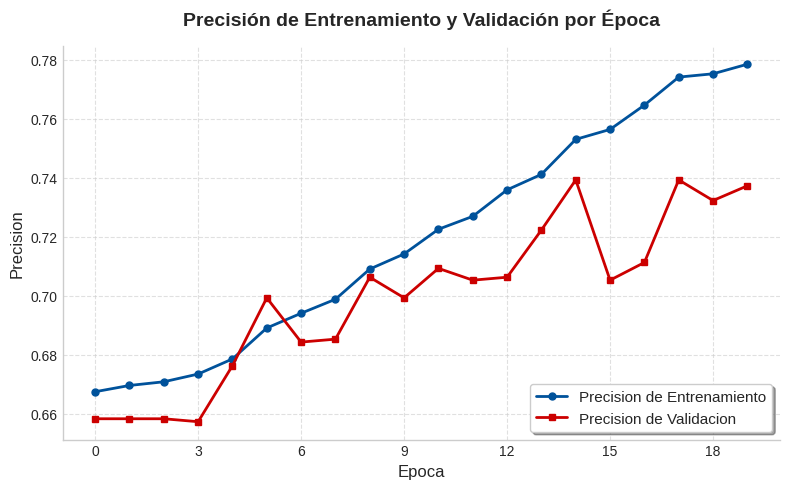

In [ ]:

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Precision de Entrenamiento", marker='o', linewidth=2, markersize=5, color='#00529B')
plt.plot(history.history["val_accuracy"], label="Precision de Validacion", marker='s', linewidth=2, markersize=5, color='#CC0000')

plt.title("Precisión de Entrenamiento y Validación por Época", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epoca", fontsize=12)
plt.ylabel("Precision", fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


plt.legend(fontsize=11, loc="lower right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
#Variable global para determinar si la etiqueta es correcta o no
def pred_cor(clase_predicha,clase_real):
  if clase_real == clase_predicha:
    resultado = "Correcta"
  else: resultado = "Incorrecta"
  return resultado


Realizamos las predicciones escogiendo 16 indices de las imagenes de prueba al azar

In [ ]:
cant_pred = 16
indices = []
for i in range (cant_pred):
  x = np.random.randint(0,len(test_images))
  indices.append(x)

print(f"Los indices de las imagenes de prueba son los siguientes: {indices}")

Los indices de las imagenes de prueba son los siguientes: [526, 696, 691, 569, 426, 509, 756, 745, 278, 237, 323, 830, 594, 812, 438, 317]


Utilizamos esos indices para graficar las 16 imagenes de prueba y determinar si la prediccion fue correcta o no y con cuanta cantidad de confianza

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step


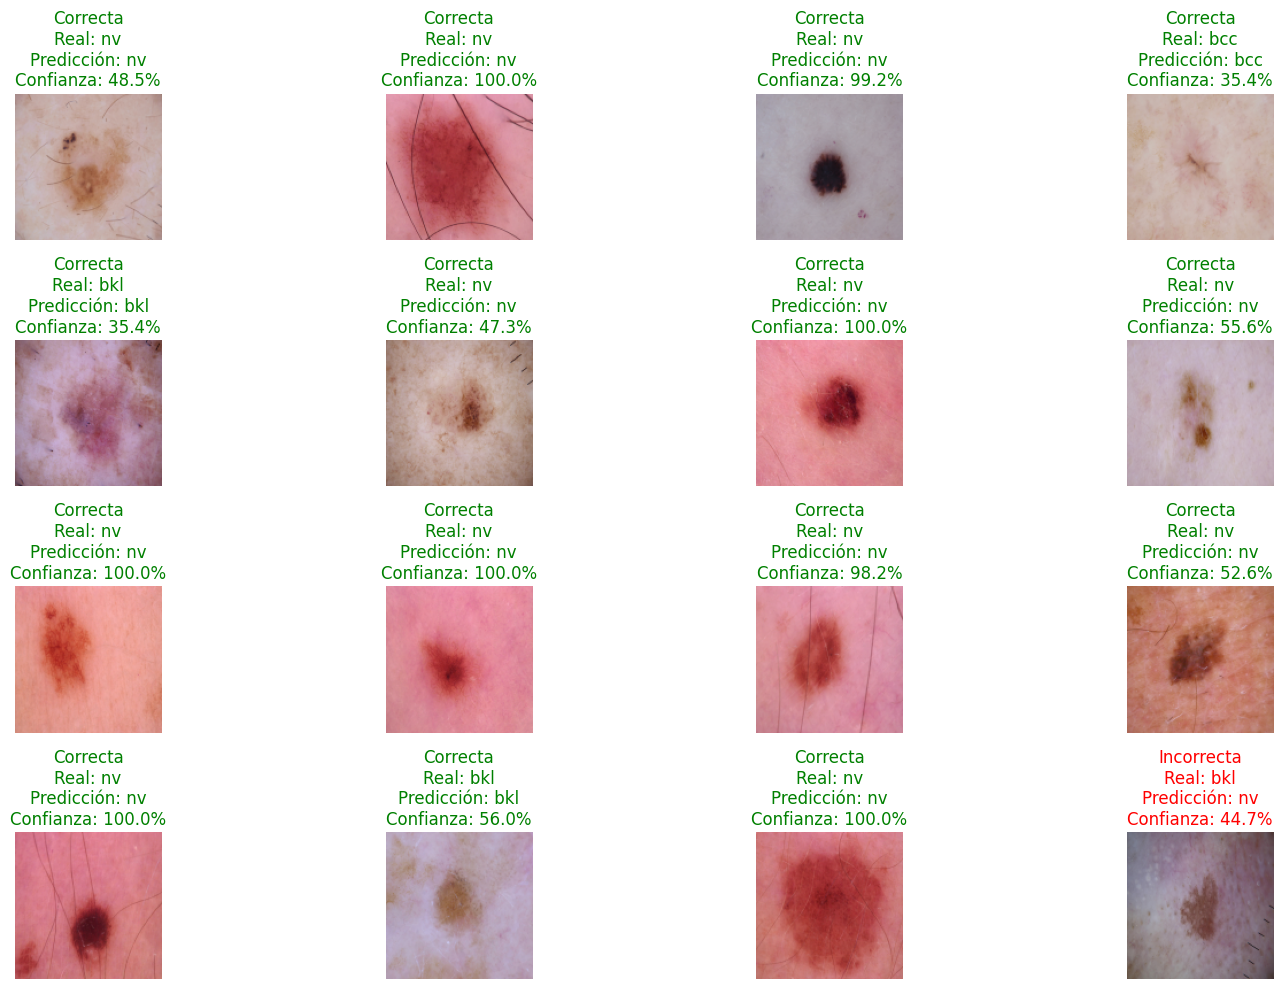

In [ ]:
imagenes_prediccion = test_images[indices]
etiquetas_reales = test_labels[indices]

predicciones_muest = model.predict(imagenes_prediccion)
etiquetas_predichas = np.argmax(predicciones_muest, axis=1)

plt.figure(figsize=(16, 10))

for i in range(len(indices)):

    plt.subplot(4, 4, i + 1)

    imagen = imagenes_prediccion[i]

    if imagen.ndim == 3 and imagen.shape[-1] == 1:
        plt.imshow(imagen.squeeze(), cmap="gray")
    else:
        plt.imshow(imagen)

    clase_real = etiquetas_reales[i]
    clase_predicha = etiquetas_predichas[i]

    nombre_real = codificador.classes_[clase_real]
    nombre_predicho = codificador.classes_[clase_predicha]

    confianza = predicciones_muest[i][clase_predicha] * 100

    plt.title(
        f"{pred_cor(clase_predicha,clase_real)}\n"
        f"Real: {nombre_real}\n"
        f"Predicción: {nombre_predicho}\n"
        f"Confianza: {confianza:.1f}%"
        ,
        color="green" if clase_real == clase_predicha else "red"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()